In [789]:
import numpy as np
import scipy as scp
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from datetime import datetime, timedelta

# Import data

In [3]:
file_path = "/home/sameervk/Documents/Jobs/Job hunt/2025/03/SmartestEnergy/wind-price-dataset-1-2.csv"

In [4]:
df = pd.read_csv(file_path, parse_dates = ['UtcDatetime'])

In [5]:
df.head(10)

,UtcDatetime,Price,Volume_MWh
0,2019-01-01 00:00:00,60.12,14.889867
1,2019-01-01 01:00:00,55.76,14.162405
2,2019-01-01 02:00:00,46.23,13.943371
3,2019-01-01 03:00:00,44.10,13.288542
4,2019-01-01 04:00:00,44.41,10.449148
5,2019-01-01 05:00:00,46.03,10.864678
6,2019-01-01 06:00:00,51.00,10.568561
7,2019-01-01 07:00:00,39.00,10.953883
8,2019-01-01 08:00:00,44.17,11.250852
9,2019-01-01 09:00:00,51.30,11.371023


# EDA

In [6]:
df.tail(10)

,UtcDatetime,Price,Volume_MWh
37237,2023-04-01 13:00:00,93.09,8.523011
37238,2023-04-01 14:00:00,95.40,7.280114
37239,2023-04-01 15:00:00,104.32,9.103030
37240,2023-04-01 16:00:00,124.99,9.020170
37241,2023-04-01 17:00:00,136.64,7.421780
37242,2023-04-01 18:00:00,131.64,4.689678
37243,2023-04-01 19:00:00,121.29,4.929261
37244,2023-04-01 20:00:00,104.99,4.860133
37245,2023-04-01 21:00:00,95.01,4.364394
37246,2023-04-01 22:00:00,114.76,3.992519


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37247 entries, 0 to 37246
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   UtcDatetime  37247 non-null  datetime64[ns]
 1   Price        37199 non-null  float64       
 2   Volume_MWh   37202 non-null  float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 873.1 KB


## Missing data

In [8]:
df.isna().value_counts()

UtcDatetime  Price  Volume_MWh
False        False  False         37154
             True   False            48
             False  True             45
Name: count, dtype: int64

#### NOTE
* There are null values in Price and Volume_MWh data

### MISSING TIME STEP

In [124]:
time_diff = np.diff(df['UtcDatetime'])

In [125]:
time_diff

array([3600000000000, 3600000000000, 3600000000000, ..., 3600000000000,
       3600000000000, 3600000000000],
      shape=(37246,), dtype='timedelta64[ns]')

In [126]:
all(time_diff == np.timedelta64(3600000000000))

True

#### NOTE
* No missing time point

### Price null values

In [9]:
df[df['Price'].isna()]

,UtcDatetime,Price,Volume_MWh
1344,2019-02-26 00:00:00,NaN,12.912784
1345,2019-02-26 01:00:00,NaN,8.206155
1346,2019-02-26 02:00:00,NaN,3.648106
1347,2019-02-26 03:00:00,NaN,3.219034
1348,2019-02-26 04:00:00,NaN,1.684564
1349,2019-02-26 05:00:00,NaN,1.111364
1350,2019-02-26 06:00:00,NaN,1.676420
1351,2019-02-26 07:00:00,NaN,2.085795
1352,2019-02-26 08:00:00,NaN,2.024242
1353,2019-02-26 09:00:00,NaN,1.497917


#### NOTE
* Price data missing for 2 days: 2019-02-26 and 2019-03-02

### Volume_MWh null values

In [10]:
df[df['Volume_MWh'].isna()]

,UtcDatetime,Price,Volume_MWh
11688,2020-05-02 00:00:00,17.50,NaN
11689,2020-05-02 01:00:00,16.00,NaN
11690,2020-05-02 02:00:00,15.31,NaN
11691,2020-05-02 03:00:00,14.86,NaN
11692,2020-05-02 04:00:00,15.00,NaN
11693,2020-05-02 05:00:00,15.71,NaN
11694,2020-05-02 06:00:00,10.00,NaN
11695,2020-05-02 07:00:00,20.88,NaN
11696,2020-05-02 08:00:00,26.00,NaN
11697,2020-05-02 09:00:00,27.23,NaN


#### NOTE
* Volume data missing for ~2 days from 2020-05-02 12 am to 2020-05-03 8 pm.

### Handling missing data

* Strategy: considering seasonality, take the average of the values of the same date and time from the other years 

In [11]:
df[df['UtcDatetime'] > np.datetime64('2019-01-02')]

,UtcDatetime,Price,Volume_MWh
25,2019-01-02 01:00:00,52.45,3.456439
26,2019-01-02 02:00:00,49.92,2.483523
27,2019-01-02 03:00:00,48.53,2.086174
28,2019-01-02 04:00:00,47.99,1.575379
29,2019-01-02 05:00:00,50.05,1.232765
...,...,...,...
37242,2023-04-01 18:00:00,131.64,4.689678
37243,2023-04-01 19:00:00,121.29,4.929261
37244,2023-04-01 20:00:00,104.99,4.860133
37245,2023-04-01 21:00:00,95.01,4.364394


In [12]:
datetime_to_fill_np = np.datetime64("2019-02-26 00:00:00")

In [101]:
datetime_to_fill_np.astype('O')

datetime.datetime(2019, 2, 26, 0, 0)

In [13]:
datetime_to_fill = datetime.fromisoformat("2019-02-26 00:00:00")
datetime_to_fill

datetime.datetime(2019, 2, 26, 0, 0)

In [14]:
datetime_to_fill.second

0

In [15]:
df[df['UtcDatetime'] > datetime.fromisoformat("2019-02-26 00:00:00")]

,UtcDatetime,Price,Volume_MWh
1345,2019-02-26 01:00:00,NaN,8.206155
1346,2019-02-26 02:00:00,NaN,3.648106
1347,2019-02-26 03:00:00,NaN,3.219034
1348,2019-02-26 04:00:00,NaN,1.684564
1349,2019-02-26 05:00:00,NaN,1.111364
...,...,...,...
37242,2023-04-01 18:00:00,131.64,4.689678
37243,2023-04-01 19:00:00,121.29,4.929261
37244,2023-04-01 20:00:00,104.99,4.860133
37245,2023-04-01 21:00:00,95.01,4.364394


In [16]:
year_to_exclude = 2019

In [17]:
years_in_data = list(range(2019, 2024, 1))
years_in_data

[2019, 2020, 2021, 2022, 2023]

In [18]:
datetime_to_fill

datetime.datetime(2019, 2, 26, 0, 0)

In [21]:
datetime_to_fill_np + timedelta(days=365)

datetime.datetime(2020, 2, 26, 0, 0)

In [22]:
datetime_to_fill.replace(year=datetime_to_fill.year + 1)

datetime.datetime(2020, 2, 26, 0, 0)

In [23]:
datetime_to_fill

datetime.datetime(2019, 2, 26, 0, 0)

In [24]:
df['Price'][df['UtcDatetime'] == datetime_to_fill.replace(year=datetime_to_fill.year + 6)].values.size

0

In [25]:
mean_value = []
year_to_exclude = datetime_to_fill.year
remaining_years = years_in_data.copy()
remaining_years.remove(year_to_exclude)
for yr in remaining_years:
    
    value = df['Price'][df['UtcDatetime'] == datetime_to_fill.replace(year=yr)].values
    if value.size!=0:
        mean_value.append(value[0])

In [26]:
mean_value

[np.float64(28.92), np.float64(45.93), np.float64(225.32), np.float64(136.47)]

In [27]:
np.mean(mean_value)

np.float64(109.16)

In [29]:
remaining_years

[2019, 2020, 2021, 2022, 2023]

In [30]:
df_copy = df.copy()

In [31]:
value = df_copy['Price'][df_copy['UtcDatetime'] == datetime_to_fill]
value

1344   NaN
Name: Price, dtype: float64

In [32]:
value.index

Index([1344], dtype='int64')

In [33]:
df_copy.loc[value.index]

,UtcDatetime,Price,Volume_MWh
1344,2019-02-26,NaN,12.912784


In [34]:
df_copy.loc[value.index, 'Price'] = np.mean(mean_value)

In [35]:
df_copy.loc[value.index]

,UtcDatetime,Price,Volume_MWh
1344,2019-02-26,109.16,12.912784


In [36]:
df_copy.loc[1344, 'UtcDatetime']

Timestamp('2019-02-26 00:00:00')

In [40]:
df_copy['test'] = df_copy.apply(lambda x: x['UtcDatetime'], axis=1)
df_copy.head(5)

,UtcDatetime,Price,Volume_MWh,test
0,2019-01-01 00:00:00,60.12,14.889867,2019-01-01 00:00:00
1,2019-01-01 01:00:00,55.76,14.162405,2019-01-01 01:00:00
2,2019-01-01 02:00:00,46.23,13.943371,2019-01-01 02:00:00
3,2019-01-01 03:00:00,44.10,13.288542,2019-01-01 03:00:00
4,2019-01-01 04:00:00,44.41,10.449148,2019-01-01 04:00:00


In [241]:
df_copy.drop(columns=['test'], inplace=True)

In [44]:
def test_func(row,col_name):
    return row[col_name]
df_copy['test'] = df_copy.apply(test_func, axis=1, col_name='Price')
df_copy.head(5)

,UtcDatetime,Price,Volume_MWh,test
0,2019-01-01 00:00:00,60.12,14.889867,60.12
1,2019-01-01 01:00:00,55.76,14.162405,55.76
2,2019-01-01 02:00:00,46.23,13.943371,46.23
3,2019-01-01 03:00:00,44.10,13.288542,44.10
4,2019-01-01 04:00:00,44.41,10.449148,44.41


In [41]:
df_copy.drop(columns=['test'], inplace=True)
df_copy.head(5)

,UtcDatetime,Price,Volume_MWh
0,2019-01-01 00:00:00,60.12,14.889867
1,2019-01-01 01:00:00,55.76,14.162405
2,2019-01-01 02:00:00,46.23,13.943371
3,2019-01-01 03:00:00,44.10,13.288542
4,2019-01-01 04:00:00,44.41,10.449148


In [112]:
df_copy['Price']=df['Price'].copy()
def fill_na_func(x, col_to_fill, years_in_data):
    if not np.isnan(x[col_to_fill]):
        return x[col_to_fill]
        
    else:
        datetime_to_fill = x['UtcDatetime']
        mean_value = []
        year_to_exclude = datetime_to_fill.year
        remaining_years = years_in_data.copy()
        remaining_years.remove(year_to_exclude)
        for yr in remaining_years:
            
            value = df_copy[col_to_fill][df_copy['UtcDatetime'] == datetime_to_fill.replace(year=yr)].values
            if value.size!=0:
                mean_value.append(value[0])
        return np.mean(mean_value)
        # return 0.0

In [113]:
df_copy

,UtcDatetime,Price,Volume_MWh,test
0,2019-01-01 00:00:00,60.12,14.889867,60.12
1,2019-01-01 01:00:00,55.76,14.162405,55.76
2,2019-01-01 02:00:00,46.23,13.943371,46.23
3,2019-01-01 03:00:00,44.10,13.288542,44.10
4,2019-01-01 04:00:00,44.41,10.449148,44.41
...,...,...,...,...
37242,2023-04-01 18:00:00,131.64,4.689678,131.64
37243,2023-04-01 19:00:00,121.29,4.929261,121.29
37244,2023-04-01 20:00:00,104.99,4.860133,104.99
37245,2023-04-01 21:00:00,95.01,4.364394,95.01


#### PRICE

In [114]:
df_copy['Price'] = df_copy.apply(fill_na_func, axis=1, col_to_fill='Price', years_in_data=years_in_data)

In [115]:
df_copy

,UtcDatetime,Price,Volume_MWh,test
0,2019-01-01 00:00:00,60.12,14.889867,60.12
1,2019-01-01 01:00:00,55.76,14.162405,55.76
2,2019-01-01 02:00:00,46.23,13.943371,46.23
3,2019-01-01 03:00:00,44.10,13.288542,44.10
4,2019-01-01 04:00:00,44.41,10.449148,44.41
...,...,...,...,...
37242,2023-04-01 18:00:00,131.64,4.689678,131.64
37243,2023-04-01 19:00:00,121.29,4.929261,121.29
37244,2023-04-01 20:00:00,104.99,4.860133,104.99
37245,2023-04-01 21:00:00,95.01,4.364394,95.01


In [116]:
df_copy['Price'][df['Price'].isna()]

1344    109.1600
1345    113.3975
1346     99.0900
1347     92.8350
1348     87.4175
1349     90.0625
1350     97.3600
1351    110.9125
1352    122.9500
1353    118.7925
1354    103.2325
1355     92.9850
1356     92.1450
1357     91.1325
1358     90.9700
1359     90.8400
1360    102.7325
1361    132.2800
1362    144.5825
1363    120.9475
1364    108.2175
1365    103.9275
1366     94.2975
1367     92.1675
1440     98.8775
1441     99.7125
1442     93.4300
1443     91.8750
1444     94.2875
1445    107.9700
1446    118.4975
1447    132.8375
1448    129.5400
1449    121.6125
1450    113.2275
1451    107.7425
1452    107.0150
1453    108.2900
1454    107.1625
1455    103.9075
1456    122.2350
1457    160.7025
1458    251.7300
1459    153.7650
1460    119.3525
1461    111.9325
1462    100.6925
1463    109.4575
Name: Price, dtype: float64

In [88]:
df.loc[1463, 'Price']

np.float64(nan)

In [86]:
df.loc[1463, 'Price'] == np.float64(np.nan)

np.False_

In [89]:
np.isnan(df.loc[1463, 'Price'])

np.True_

In [90]:
np.isnan(df.loc[1463, 'Price']) == True

np.True_

In [91]:
if np.isnan(df.loc[1463, 'Price']) == True:
    print('ok')

ok


In [106]:
df.loc[1463, 'UtcDatetime']

Timestamp('2019-03-02 23:00:00')

In [107]:
x = df.loc[1463, 'UtcDatetime']

In [111]:
x.replace(year=2020)

Timestamp('2020-03-02 23:00:00')

#### Volume

In [117]:
df_copy['Volume_MWh'] = df_copy.apply(fill_na_func, axis=1, col_to_fill='Volume_MWh', years_in_data=years_in_data)

In [118]:
df_copy['Volume_MWh'][df['Volume_MWh'].isna()]

11688     2.091951
11689     1.950063
11690     2.138605
11691     1.937910
11692     1.866288
11693     1.771559
11694     2.024527
11695     2.380145
11696     3.551515
11697     3.325789
11698     4.552525
11699     7.028504
11700     8.473264
11701     9.612563
11702     9.038542
11703     9.499684
11704     7.273611
11705     7.539236
11706     6.515562
11707     3.909659
11708     3.854261
11709     3.135164
11710     3.223011
11711     3.550410
11712     3.973295
11713     3.379640
11714     3.530650
11715     4.532513
11716     5.285354
11717     5.905114
11718     6.531755
11719     9.605777
11720    13.407765
11721    16.715751
11722    18.454924
11723    19.707513
11724    19.550726
11725    20.470328
11726    21.305713
11727    20.860890
11728    21.058902
11729    22.129451
11730    17.572348
11731    19.822475
11732    20.770644
Name: Volume_MWh, dtype: float64

#### FINAL CHECK

In [119]:
df_copy.isna().sum()

UtcDatetime     0
Price           0
Volume_MWh      0
test           47
dtype: int64

## DUPLICATES

In [121]:
df_copy.duplicated(subset='UtcDatetime')

0        False
1        False
2        False
3        False
4        False
         ...  
37242    False
37243    False
37244    False
37245    False
37246    False
Length: 37247, dtype: bool

In [123]:
df_copy['UtcDatetime'].duplicated().sum()

np.int64(0)

### NOTE
* No time duplicates

## PLOT 1: PRICE

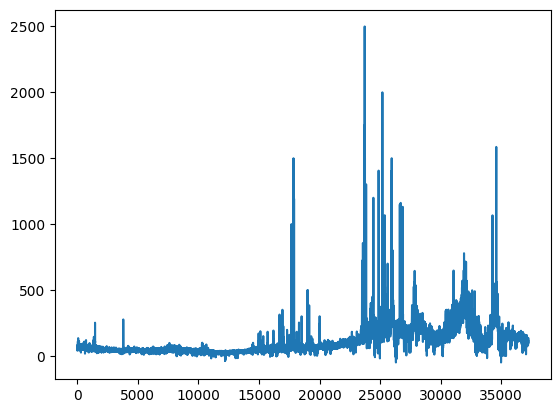

In [127]:
plt.plot(df_copy['Price'])
plt.show()

#### NOTE

* On a high level, there does not appear to any cycles but quite a number of sharp anomalous price rises.
* Further check is required

## PLOT 2: POWER GENERATION

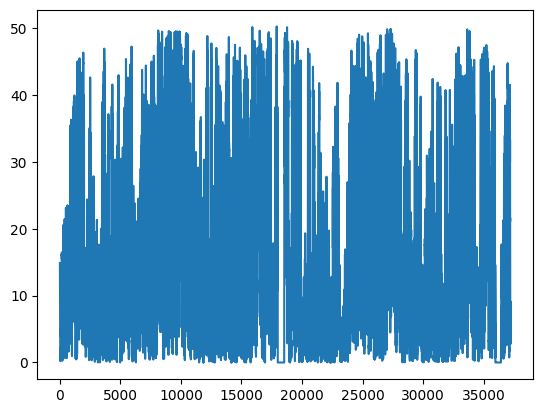

In [128]:
plt.plot(df_copy['Volume_MWh'])
plt.show()

#### NOTE

* On a high level, there does appears to be some sort of seasonality in electricity generation.
* Further check is required

## Correlation

In [244]:
df_corr = df_copy[['Price', 'Volume_MWh']].corr(method='pearson')
df_corr

,Price,Volume_MWh
Price,1.000000,-0.134439
Volume_MWh,-0.134439,1.000000


In [245]:
df_corr_sp = df_copy[['Price', 'Volume_MWh']].corr(method='spearman')
df_corr_sp

,Price,Volume_MWh
Price,1.000000,-0.153189
Volume_MWh,-0.153189,1.000000


### NOTE
* No correlation between price and volume

In [ ]:
df_copy['Price'] - df_copy['Base Price']

## DISTRIBUTION

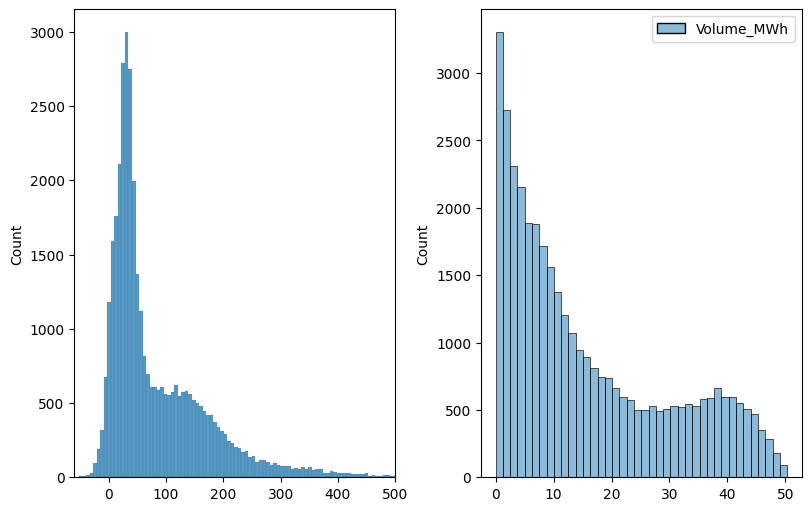

In [784]:
fig, ax = plt.subplots(1,2, figsize=(8,5), constrained_layout=True)
sns.histplot(df_copy['Price']-df_copy['Base Price'], ax=ax[0])
sns.histplot(df_copy[['Volume_MWh']], ax=ax[1])
ax[0].set_xlim([-60,500])
plt.show()

In [781]:
df_copy.columns

Index(['UtcDatetime', 'Price', 'Volume_MWh', 'Base Price', 'time_cosine',
       'time_sine'],
      dtype='object')

In [777]:
df_copy[['Price', 'Volume_MWh']].describe()

,Price,Volume_MWh
count,37247.000000,37247.000000
mean,101.712287,15.861249
std,100.036766,13.856450
min,-50.080000,0.000000
25%,38.000000,4.345360
50%,60.010000,11.039205
75%,142.455000,25.857008
max,2500.010000,50.284186


#### NOTE
* The distribution of Price data is not exactly normal. It appears this data can be fit using two Gaussian curves.
* For the generation, the number of 0 counts is the highest. Distribution is not a normal distribution.
* Transformation methods such as Log require the data to be strictly positive. Hence, for the instances with zero values, a small $\epsilon=0.0001$ will be added to Volume_MWh.

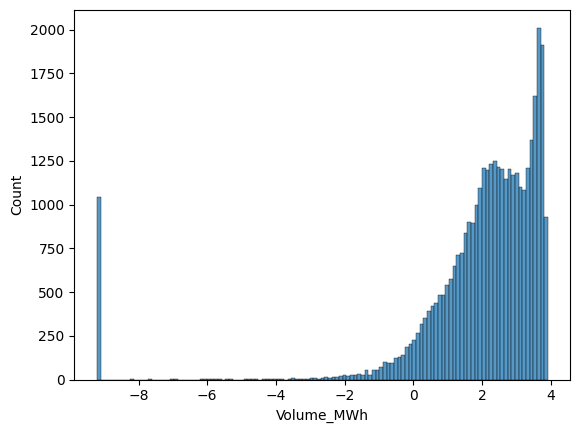

In [787]:
sns.histplot(np.log(df_copy['Volume_MWh'].map(lambda x: 0.0001 if x==0.0 else x)))
plt.show()

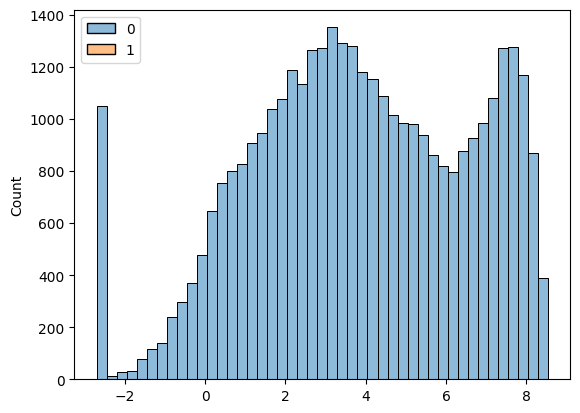

In [788]:
sns.histplot(scp.stats.boxcox(df_copy['Volume_MWh'].map(lambda x: 0.0001 if x==0.0 else x)))
plt.show()

In [790]:
from sklearn.preprocessing import StandardScaler

In [792]:
sc_price_fit = StandardScaler().fit_transform(df_copy[['Price']])

In [793]:
sc_price_fit.min()

np.float64(-1.5173853595569458)

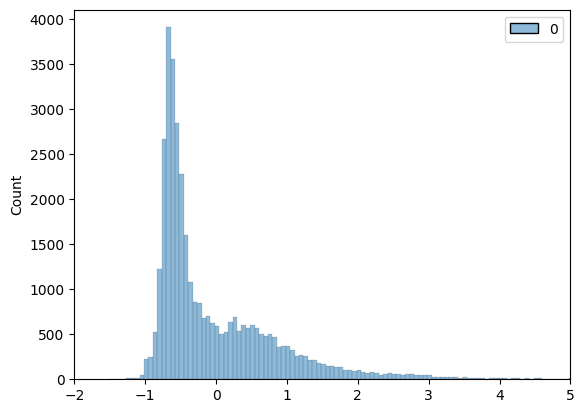

In [795]:
sns.histplot(sc_price_fit)
plt.xlim([-2,5])
plt.show()

In [796]:
sc_volume_fit = StandardScaler().fit_transform(df_copy[['Volume_MWh']])
sc_volume_fit.min()

np.float64(-1.1446988140462315)

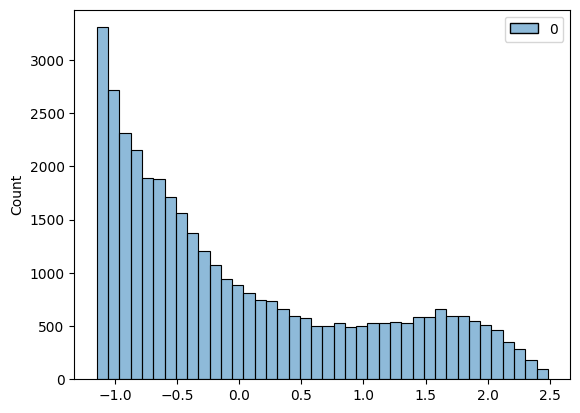

In [798]:
sns.histplot(sc_volume_fit)
# plt.xlim([-2,5])
plt.show()

# PRICE MODEL

In [129]:
from scipy.fft import fft, ifft, fftfreq

In [893]:
fft_price = fft(df_copy['Price'])

In [894]:
len(fft_price)

37247

In [133]:
sampling_rate = 1/3600 # Hz

In [895]:
freq_values = fftfreq(len(fft_price), d=3600)
freq_values[:10]

array([0.00000000e+00, 7.45772217e-09, 1.49154443e-08, 2.23731665e-08,
       2.98308887e-08, 3.72886109e-08, 4.47463330e-08, 5.22040552e-08,
       5.96617774e-08, 6.71194996e-08])

In [135]:
freq_in_periods = 1/freq_values * sampling_rate

/tmp/ipykernel_380706/465146520.py:1: RuntimeWarning: divide by zero encountered in divide
  freq_in_periods = 1/freq_values * sampling_rate


## FFT

### PLOT 3: FFT of Price

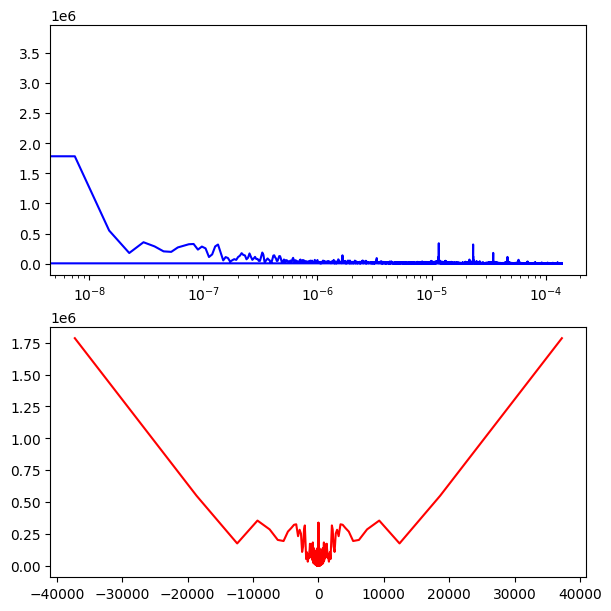

In [827]:
fig, ax = plt.subplots(2,1, figsize=(6, 6), constrained_layout=True)

ax[0].semilogx(freq_values, np.abs(fft_price), 'b', label="Frequency space")
ax[1].plot(freq_in_periods, np.abs(fft_price), 'r', label="Time space")

# ax[0].set_xlim([1*10**(-7),2.9*10**(-7)])
# ax[1].set_xlim([0,20000])
plt.show()

#### NOTE

* There are distinct frequencies in the price cycles

### Fundamental frequency

In [177]:
freq_values_one_side = freq_values[:len(fft_price)//2].copy()
fft_price_one_side = fft_price[:len(fft_price)//2].copy()

#### PLOT 4

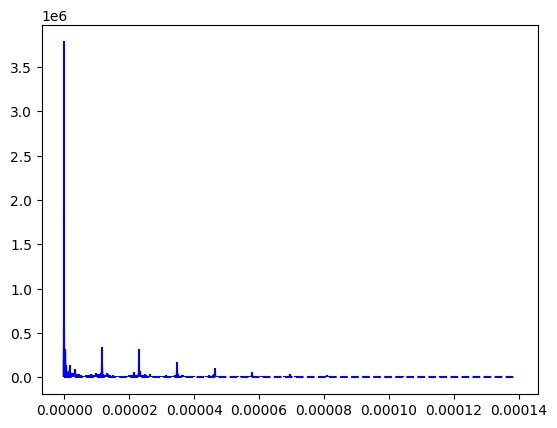

In [179]:
plt.stem(freq_values_one_side, abs(fft_price_one_side), 'b', markerfmt="", basefmt="--b")
# plt.xlim(0.0000230, 0.0000240)
plt.show()

In [180]:
freq_0_abs_val = np.max(abs(fft_price_one_side[(freq_values_one_half>1.15*10**(-5)) & (freq_values_one_half<1.16*10**(-5))]))
freq_0_abs_val

np.float64(338335.53669670696)

In [182]:
freq_0_idx = np.argwhere(abs(fft_price_one_side) == freq_0_abs_val)
freq_0_idx

array([[1552]])

In [185]:
freq_0 = freq_values_one_side[freq_0_idx[0]]
freq_0

array([1.15743848e-05])

In [186]:
# corresponding time value in hours
time_0 = 1/freq_0*sampling_rate
time_0

array([23.99935567])

#### NOTE
* There is a cycling price component in the data with a primary frequency of 24 hours.

#### Second harmonic

In [187]:
freq_1_abs_val = np.max(abs(fft_price_one_side[(freq_values_one_side>2.15*10**(-5)) & (freq_values_one_side<2.32*10**(-5))]))
freq_1_abs_val

np.float64(318145.57656009216)

In [188]:
freq_1_idx = np.argwhere(abs(fft_price_one_side) == freq_1_abs_val)
freq_1_idx

array([[3104]])

In [191]:
# confirms the secondary frequency value
assert freq_1_idx[0] == freq_0_idx[0]*2

In [189]:
freq_1 = freq_values_one_side[freq_1_idx[0]]
freq_1

array([2.31487696e-05])

In [194]:
freq_1 == freq_0 * 2

array([ True])

#### NOTE

* Secondary frequency is twice that of the primary frequency.
* Other primary frequencies can be extracted through in-depth analysis. However, for this exercise, only this mode is considered.
* A quick test identified 7 days and 89 days (~ 3 months) frequencies

### INVERSE

* From Plot 4, about 7 peaks can be identified

In [199]:
freq_0_idx[0]

array([1552])

In [203]:
freq_price_indices = np.linspace(freq_0_idx[0], freq_0_idx[0]*7, num=7, dtype=int).flatten()
freq_price_indices

array([ 1552,  3104,  4656,  6208,  7760,  9312, 10864])

In [204]:
# zero all fft price values except for these indices and the corresponding indices of the negative frequencies
fft_price[-1*freq_price_indices]

array([-154921.06647806-300782.97583665j,
       -253757.19569285-191895.52761556j,
         56851.70962911+168634.38284073j,
        106790.91581181 +30653.87747469j,
        -25475.65341326 -58022.24301413j,
        -34008.65404546  +9967.34005994j,
          9052.73695042 +16378.57378831j])

In [205]:
fft_price[freq_price_indices]

array([-154921.06647806+300782.97583665j,
       -253757.19569285+191895.52761556j,
         56851.70962911-168634.38284073j,
        106790.91581181 -30653.87747469j,
        -25475.65341326 +58022.24301413j,
        -34008.65404546  -9967.34005994j,
          9052.73695042 -16378.57378831j])

In [207]:
fft_price_copy = np.zeros_like(fft_price)

In [208]:
fft_price_copy[freq_price_indices] = fft_price[freq_price_indices]

In [210]:
fft_price_copy[freq_price_indices]

array([-154921.06647806+300782.97583665j,
       -253757.19569285+191895.52761556j,
         56851.70962911-168634.38284073j,
        106790.91581181 -30653.87747469j,
        -25475.65341326 +58022.24301413j,
        -34008.65404546  -9967.34005994j,
          9052.73695042 -16378.57378831j])

In [209]:
fft_price_copy[-1*freq_price_indices] = fft_price[-1*freq_price_indices]

In [211]:
fft_price_copy[-1*freq_price_indices]

array([-154921.06647806-300782.97583665j,
       -253757.19569285-191895.52761556j,
         56851.70962911+168634.38284073j,
        106790.91581181 +30653.87747469j,
        -25475.65341326 -58022.24301413j,
        -34008.65404546  +9967.34005994j,
          9052.73695042 +16378.57378831j])

In [216]:
# verifying
np.where(fft_price_copy==0.0)[0].size == len(fft_price) - 2 * len(freq_price_indices)

True

In [217]:
ifft_price = ifft(fft_price_copy)

In [218]:
len(ifft_price)

37247

In [904]:
fft_price_copy = np.copy(fft_price)
fft_price_copy[freq_values>10**(-5)]=0.0
fft_price_copy[freq_values<-10**(-5)]=0.0
fft_price_copy[freq_price_indices] = fft_price[freq_price_indices]
fft_price_copy[-1*freq_price_indices] = fft_price[-1*freq_price_indices]

In [905]:
fft_price_copy[fft_price_copy == 0.0].size

34566

In [906]:
len(fft_price_copy) - fft_price_copy[fft_price_copy == 0.0].size

2681

In [908]:
ifft_price = ifft(fft_price_copy)

In [898]:
fft_price[fft_price == 0.0].size

0

#### PLOT 5

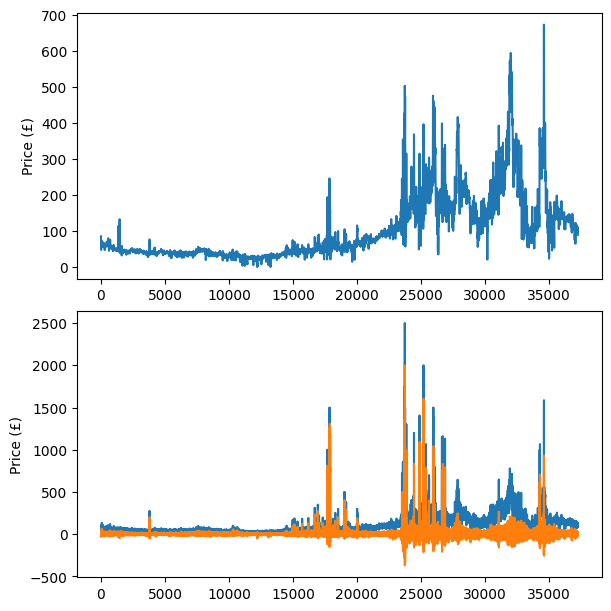

In [909]:
fig, ax = plt.subplots(2,1, figsize=(6,6), constrained_layout=True)
ax[0].plot(abs(ifft_price), label='Primary price mode')
# ax[0].set_xlim([0,48])
ax[1].plot(df['Price'], label="N2EX price")
ax[1].plot(df['Price'] - abs(ifft_price), label="N2EX - base fft price")
[i.set_ylabel('Price (£)') for i in ax]
plt.show()

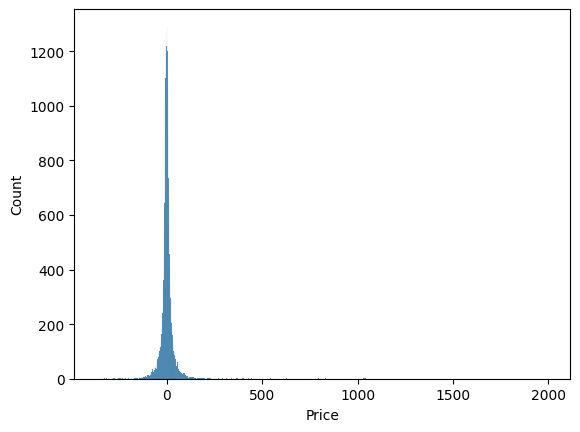

In [910]:
sns.histplot(df['Price'] - abs(ifft_price))
plt.show()

In [228]:
df.head(24)

,UtcDatetime,Price,Volume_MWh
0,2019-01-01 00:00:00,60.12,14.889867
1,2019-01-01 01:00:00,55.76,14.162405
2,2019-01-01 02:00:00,46.23,13.943371
3,2019-01-01 03:00:00,44.10,13.288542
4,2019-01-01 04:00:00,44.41,10.449148
5,2019-01-01 05:00:00,46.03,10.864678
6,2019-01-01 06:00:00,51.00,10.568561
7,2019-01-01 07:00:00,39.00,10.953883
8,2019-01-01 08:00:00,44.17,11.250852
9,2019-01-01 09:00:00,51.30,11.371023


* In the top figure, the cycle is of 24 hours frequency for the price.
* This corresponds to time 00:00:00 to 23:00:00
* For the Price minus FFT base price, a machine learning model using Quantile Regression can be fit

#### BASE PRICE FROM FFT

In [229]:
base_fft_price = abs(ifft_price)[:24]
base_fft_price

array([15.86528887, 18.41807218, 22.81043371, 26.73957648, 26.40905488,
       20.05805661,  8.01250061,  4.2317715 ,  9.59455547,  8.39764145,
        5.06565697,  0.67605273,  3.57087252,  5.83137057,  7.89421063,
        6.40435139,  9.9614507 , 37.32069343, 50.38612874, 37.17789585,
       15.33276226,  1.80639407,  5.78235747, 12.16422768])

In [236]:
from math import ceil

In [237]:
num_days = ceil(len(df_copy)/len(base_fft_price))
num_days

1552

In [238]:
base_fft_price_arr = base_fft_price.tolist()*num_days

In [239]:
df_copy['Base Price'] = base_fft_price_arr[:len(df_copy)]

In [242]:
df_copy

,UtcDatetime,Price,Volume_MWh,Base Price
0,2019-01-01 00:00:00,60.12,14.889867,15.865289
1,2019-01-01 01:00:00,55.76,14.162405,18.418072
2,2019-01-01 02:00:00,46.23,13.943371,22.810434
3,2019-01-01 03:00:00,44.10,13.288542,26.739576
4,2019-01-01 04:00:00,44.41,10.449148,26.409055
...,...,...,...,...
37242,2023-04-01 18:00:00,131.64,4.689678,50.386129
37243,2023-04-01 19:00:00,121.29,4.929261,37.177896
37244,2023-04-01 20:00:00,104.99,4.860133,15.332762
37245,2023-04-01 21:00:00,95.01,4.364394,1.806394


##### VERIFYING

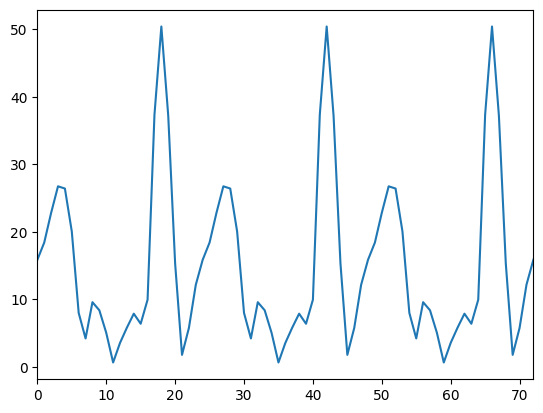

In [243]:
plt.plot(df_copy['Base Price'])
plt.xlim([0,72])
plt.show()

## Autocorrelation

In [747]:
from statsmodels.graphics import tsaplots
import statsmodels.api as sm

In [748]:
acf_price = sm.tsa.acf(df_copy['Price'].to_numpy(), nlags=len(df_copy))

In [749]:
len(acf_price)

37247

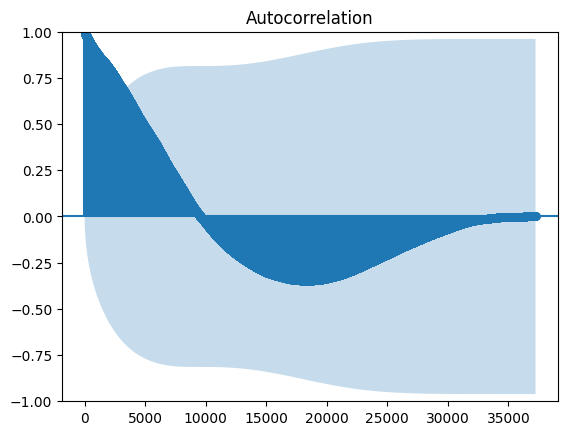

In [755]:
tsaplots.plot_acf(acf_price, lags=len(df_copy)-1)
# plt.xlim([10000,25000])
plt.show()

In [754]:
18000/24

750.0

## REGRESSION MODELS

* We could use GradientBoostingRegressor for calculating P10 and P90.

### Convert time to Sine and Cosine features

In [248]:
x = df_copy.loc[0,'UtcDatetime']
x

Timestamp('2019-01-01 00:00:00')

In [249]:
x.value

1546300800000000000

In [250]:
df_copy['time_cosine'] = np.cos(df_copy['UtcDatetime'].map(lambda x:x.value))

In [251]:
df_copy['time_sine'] = np.sin(df_copy['UtcDatetime'].map(lambda x:x.value))

In [252]:
df_copy.head(10)

,UtcDatetime,Price,Volume_MWh,Base Price,time_cosine,time_sine
0,2019-01-01 00:00:00,60.12,14.889867,15.865289,0.213888,0.976858
1,2019-01-01 01:00:00,55.76,14.162405,18.418072,0.970275,0.242004
2,2019-01-01 02:00:00,46.23,13.943371,22.810434,0.647588,-0.761991
3,2019-01-01 03:00:00,44.10,13.288542,26.739576,-0.395303,-0.918551
4,2019-01-01 04:00:00,44.41,10.449148,26.409055,-0.998565,-0.053561
5,2019-01-01 05:00:00,46.03,10.864678,20.058057,-0.491291,0.870995
6,2019-01-01 06:00:00,51.00,10.568561,8.012501,0.562363,0.826890
7,2019-01-01 07:00:00,39.00,10.953883,4.231772,0.990595,-0.136826
8,2019-01-01 08:00:00,44.17,11.250852,9.594555,0.317155,-0.948374
9,2019-01-01 09:00:00,51.30,11.371023,8.397641,-0.709004,-0.705205


### Data preparation for training

#### NOTE

* As N2EX prices are day-ahead prices, the model will be designed to predict prices 24h in the future

In [253]:
df_price = pd.DataFrame()
df_price['Price'] = df_copy['Price']-df_copy['Base Price'] # removing the base fft price
df_price['time_cosine'] = df_copy['time_cosine']
df_price['time_sine'] = df_copy['time_sine']
df_price

,Price,time_cosine,time_sine
0,44.254711,0.213888,0.976858
1,37.341928,0.970275,0.242004
2,23.419566,0.647588,-0.761991
3,17.360424,-0.395303,-0.918551
4,18.000945,-0.998565,-0.053561
...,...,...,...
37242,81.253871,0.553580,0.832796
37243,84.112104,0.991988,-0.126334
37244,89.657238,0.327175,-0.944964
37245,93.203606,-0.701500,-0.712670


In [264]:
train_x = df_price.iloc[:-24, :]
train_x

,Price,time_cosine,time_sine
0,44.254711,0.213888,0.976858
1,37.341928,0.970275,0.242004
2,23.419566,0.647588,-0.761991
3,17.360424,-0.395303,-0.918551
4,18.000945,-0.998565,-0.053561
...,...,...,...
37218,68.143871,-0.807612,0.589714
37219,72.832104,0.169892,0.985463
37220,92.677238,0.958454,0.285247
37221,95.273606,0.681089,-0.732201


In [265]:
train_y = df_price.iloc[24:, 0]
train_y

24        36.094711
25        34.031928
26        27.109566
27        21.790424
28        21.580945
            ...    
37242     81.253871
37243     84.112104
37244     89.657238
37245     93.203606
37246    108.977643
Name: Price, Length: 37223, dtype: float64

In [266]:
train_test_split_ratio = 0.8
split_size = int(len(train_x)*train_test_split_ratio)
split_size

29778

In [267]:
test_x = train_x[split_size:].to_numpy()
test_y = train_y[split_size:].to_numpy()

In [271]:
test_x.shape, test_y.shape

((7445, 3), (7445,))

In [272]:
train_x = train_x[:split_size].to_numpy()
train_y = train_y[:split_size].to_numpy()

In [273]:
train_x.shape, train_y.shape

((29778, 3), (29778,))

### Expected Prices

* Given the several anomalous price rises, using 50th percentile or median for expected prices

In [274]:
from sklearn.ensemble import GradientBoostingRegressor

In [275]:
model_price_expected = GradientBoostingRegressor(loss='quantile',
                                                alpha=0.5,
                                                n_estimators=1000
                                                )

In [276]:
model_price_expected.fit(train_x, train_y)

GradientBoostingRegressor(alpha=0.5, loss='quantile', n_estimators=1000)

In [277]:
model_price_expected.score(train_x, train_y)

0.7617761483087601

#### Test data score

In [278]:
model_price_expected.score(test_x, test_y)

0.686717654733624

* The $R^{2}$ score is reasonable.

### 10th percentile Prices

In [279]:
model_price_p10 = GradientBoostingRegressor(loss='quantile',
                                            alpha=0.1,
                                            n_estimators=1000
                                            )

In [280]:
model_price_p10.fit(train_x, train_y)

GradientBoostingRegressor(alpha=0.1, loss='quantile', n_estimators=1000)

In [281]:
model_price_p10.score(train_x, train_y)

0.5673938609544316

#### Test data score

In [282]:
model_price_p10.score(test_x, test_y)

0.1867748164551264

* The $R^{2}$ score is terrible.

### 90th percentile Prices

In [283]:
model_price_p90 = GradientBoostingRegressor(loss='quantile',
                                            alpha=0.9,
                                            n_estimators=1000
                                            )

In [284]:
model_price_p90.fit(train_x, train_y)

GradientBoostingRegressor(loss='quantile', n_estimators=1000)

In [285]:
model_price_p90.score(train_x, train_y)

0.6160025529991036

#### Test data score

In [286]:
model_price_p90.score(test_x, test_y)

0.5295182503522913

* The $R^{2}$ score is ok.

#### NOTE

* Hyperparameter optimisation could probably increase the $R^{2}$ to an extent.
* However, other factors that are not considered here such as total electricity supply, demand, gas prices, etc will play a significant role in estimating the prices

### PREDICTION

In [443]:
x = df_copy.loc[24, 'UtcDatetime']
x

Timestamp('2019-01-02 00:00:00')

In [444]:
x + timedelta(hours=1)

Timestamp('2019-01-02 01:00:00')

In [445]:
x.hour

0

In [446]:
x

Timestamp('2019-01-02 00:00:00')

In [447]:
last_time_point = df_copy.iloc[-1,0]
last_time_point

Timestamp('2023-04-01 22:00:00')

In [658]:
time_range = datetime.fromisoformat("2024-03-31 23:00:00") - last_time_point
time_range

Timedelta('365 days 01:00:00')

In [659]:
total_num_hours = time_range.total_seconds()/3600
total_num_hours

8761.0

In [660]:
df_price_23_24 = pd.DataFrame(columns=['UtcDatetime', 'time_cosine', 'time_sine', 
                                       'Expected Price', 'P10', 'P90'])

In [661]:
df_price_23_24['UtcDatetime']=[last_time_point + timedelta(hours=i) for i in range(1, int(total_num_hours)+1)]

In [662]:
df_price_23_24

,UtcDatetime,time_cosine,time_sine,Expected Price,P10,P90
0,2023-04-01 23:00:00,NaN,NaN,NaN,NaN,NaN
1,2023-04-02 00:00:00,NaN,NaN,NaN,NaN,NaN
2,2023-04-02 01:00:00,NaN,NaN,NaN,NaN,NaN
3,2023-04-02 02:00:00,NaN,NaN,NaN,NaN,NaN
4,2023-04-02 03:00:00,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
8756,2024-03-31 19:00:00,NaN,NaN,NaN,NaN,NaN
8757,2024-03-31 20:00:00,NaN,NaN,NaN,NaN,NaN
8758,2024-03-31 21:00:00,NaN,NaN,NaN,NaN,NaN
8759,2024-03-31 22:00:00,NaN,NaN,NaN,NaN,NaN


In [663]:
df_price_23_24['time_cosine'] = np.cos(df_price_23_24['UtcDatetime'].map(lambda x: x.value))
df_price_23_24['time_sine'] = np.sin(df_price_23_24['UtcDatetime'].map(lambda x: x.value))

In [664]:
df_price_23_24.head(10)

,UtcDatetime,time_cosine,time_sine,Expected Price,P10,P90
0,2023-04-01 23:00:00,-0.141987,0.989868,NaN,NaN,NaN
1,2023-04-02 00:00:00,0.823948,0.566665,NaN,NaN,NaN
2,2023-04-02 01:00:00,0.873544,-0.486745,NaN,NaN,NaN
3,2023-04-02 02:00:00,-0.048356,-0.998830,NaN,NaN,NaN
4,2023-04-02 03:00:00,-0.916478,-0.400085,NaN,NaN,NaN
5,2023-04-02 04:00:00,-0.765356,0.643608,NaN,NaN,NaN
6,2023-04-02 05:00:00,0.236943,0.971523,NaN,NaN,NaN
7,2023-04-02 06:00:00,0.975730,0.218977,NaN,NaN,NaN
8,2023-04-02 07:00:00,0.629376,-0.777101,NaN,NaN,NaN
9,2023-04-02 08:00:00,-0.416927,-0.908940,NaN,NaN,NaN


In [665]:
df_copy.iloc[-24, [0]].to_frame().T

,UtcDatetime
37223,2023-03-31 23:00:00


In [666]:
model_price_expected.predict(np.array([[0,0,0]]))

array([1.252366])

In [667]:
def price_prediction_function(current_time_val, 
                              last_time_val, 
                              base_price,
                              model,
                              feature
                             ):

    base_price_to_add = base_fft_price_arr[current_time_val.UtcDatetime.hour]
    x_features = np.array([[last_time_val[feature], last_time_val['time_cosine'], last_time_val['time_sine']]])
    predicted_price = model.predict(x_features) + base_price_to_add
    return predicted_price

In [668]:
df_price_23_24.iloc[0]['UtcDatetime'].hour

23

In [669]:
df_copy.iloc[-24]

UtcDatetime    2023-03-31 23:00:00
Price                         80.0
Volume_MWh                 4.78608
Base Price               12.164228
time_cosine              -0.995161
time_sine                -0.098262
Name: 37223, dtype: object

In [670]:
price_prediction_function(current_time_val=df_price_23_24.iloc[0],
                         last_time_val=df_copy.iloc[-24],
                          base_price=base_fft_price_arr,
                         model=model_price_expected,
                          feature='Price'
                         )

array([90.34341577])

#### SEED DATA

In [671]:
df_prediction_seed = df_copy[(df_copy['UtcDatetime']>=datetime.fromisoformat("2023-03-31")) & 
(df_copy['UtcDatetime']<datetime.fromisoformat("2023-04-01"))].copy()
df_prediction_seed

,UtcDatetime,Price,Volume_MWh,Base Price,time_cosine,time_sine
37200,2023-03-31 00:00:00,110.03,9.989205,15.865289,-0.870609,-0.491975
37201,2023-03-31 01:00:00,102.60,9.048485,18.418072,-0.827332,0.561713
37202,2023-03-31 02:00:00,93.14,8.374905,22.810434,0.136047,0.990702
37203,2023-03-31 03:00:00,81.81,7.403030,26.739576,0.948124,0.317900
37204,2023-03-31 04:00:00,96.93,4.818750,26.409055,0.705762,-0.708449
37205,2023-03-31 05:00:00,114.97,4.910985,20.058057,-0.321501,-0.946909
37206,2023-03-31 06:00:00,110.03,4.757670,8.012501,-0.991212,-0.132281
37207,2023-03-31 07:00:00,114.54,4.495170,4.231772,-0.558565,0.829461
37208,2023-03-31 08:00:00,125.46,3.327462,9.594555,0.495281,0.868733
37209,2023-03-31 09:00:00,127.14,2.821686,8.397641,0.998308,-0.058141


In [672]:
# renaming price to expected price
df_prediction_seed.rename(columns={'Price':'Expected Price'}, inplace=True)
df_prediction_seed

,UtcDatetime,Expected Price,Volume_MWh,Base Price,time_cosine,time_sine
37200,2023-03-31 00:00:00,110.03,9.989205,15.865289,-0.870609,-0.491975
37201,2023-03-31 01:00:00,102.60,9.048485,18.418072,-0.827332,0.561713
37202,2023-03-31 02:00:00,93.14,8.374905,22.810434,0.136047,0.990702
37203,2023-03-31 03:00:00,81.81,7.403030,26.739576,0.948124,0.317900
37204,2023-03-31 04:00:00,96.93,4.818750,26.409055,0.705762,-0.708449
37205,2023-03-31 05:00:00,114.97,4.910985,20.058057,-0.321501,-0.946909
37206,2023-03-31 06:00:00,110.03,4.757670,8.012501,-0.991212,-0.132281
37207,2023-03-31 07:00:00,114.54,4.495170,4.231772,-0.558565,0.829461
37208,2023-03-31 08:00:00,125.46,3.327462,9.594555,0.495281,0.868733
37209,2023-03-31 09:00:00,127.14,2.821686,8.397641,0.998308,-0.058141


In [673]:
df_price_seed = pd.DataFrame(columns=df_price_23_24.columns)
df_price_seed[['UtcDatetime', 'time_cosine', 'time_sine', 
                                       'Expected Price']]=df_prediction_seed[['UtcDatetime', 'time_cosine', 'time_sine', 
                                       'Expected Price']].copy()
df_price_seed

,UtcDatetime,time_cosine,time_sine,Expected Price,P10,P90
37200,2023-03-31 00:00:00,-0.870609,-0.491975,110.03,NaN,NaN
37201,2023-03-31 01:00:00,-0.827332,0.561713,102.60,NaN,NaN
37202,2023-03-31 02:00:00,0.136047,0.990702,93.14,NaN,NaN
37203,2023-03-31 03:00:00,0.948124,0.317900,81.81,NaN,NaN
37204,2023-03-31 04:00:00,0.705762,-0.708449,96.93,NaN,NaN
37205,2023-03-31 05:00:00,-0.321501,-0.946909,114.97,NaN,NaN
37206,2023-03-31 06:00:00,-0.991212,-0.132281,110.03,NaN,NaN
37207,2023-03-31 07:00:00,-0.558565,0.829461,114.54,NaN,NaN
37208,2023-03-31 08:00:00,0.495281,0.868733,125.46,NaN,NaN
37209,2023-03-31 09:00:00,0.998308,-0.058141,127.14,NaN,NaN


In [674]:
# reset index
df_price_concat = pd.concat([df_price_seed, df_price_23_24], ignore_index=True)
df_price_concat

/tmp/ipykernel_380706/2721361334.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_price_concat = pd.concat([df_price_seed, df_price_23_24], ignore_index=True)


,UtcDatetime,time_cosine,time_sine,Expected Price,P10,P90
0,2023-03-31 00:00:00,-0.870609,-0.491975,110.03,NaN,NaN
1,2023-03-31 01:00:00,-0.827332,0.561713,102.60,NaN,NaN
2,2023-03-31 02:00:00,0.136047,0.990702,93.14,NaN,NaN
3,2023-03-31 03:00:00,0.948124,0.317900,81.81,NaN,NaN
4,2023-03-31 04:00:00,0.705762,-0.708449,96.93,NaN,NaN
...,...,...,...,...,...,...
8780,2024-03-31 19:00:00,-0.240447,0.970662,NaN,NaN,NaN
8781,2024-03-31 20:00:00,0.763028,0.646365,NaN,NaN,NaN
8782,2024-03-31 21:00:00,0.917916,-0.396776,NaN,NaN,NaN
8783,2024-03-31 22:00:00,0.051960,-0.998649,NaN,NaN,NaN


In [675]:
for row in df_price_concat.iloc[24:].itertuples():

    # print(row)
    df_price_concat.loc[row.Index, 'Expected Price'] = price_prediction_function(current_time_val=row,
                                                                                last_time_val=df_price_concat.iloc[row.Index-24],
                                                                                base_price=base_fft_price_arr,
                                                                                model=model_price_expected,
                                                                                 feature='Expected Price'
                                                                                )
    df_price_concat.loc[row.Index, 'P10'] = price_prediction_function(current_time_val=row,
                                                                                last_time_val=df_price_concat.iloc[row.Index-24],
                                                                                base_price=base_fft_price_arr,
                                                                                model=model_price_p10,
                                                                      feature='Expected Price'
                                                                                )
    df_price_concat.loc[row.Index, 'P90'] = price_prediction_function(current_time_val=row,
                                                                                last_time_val=df_price_concat.iloc[row.Index-24],
                                                                                base_price=base_fft_price_arr,
                                                                                model=model_price_p90,
                                                                      feature='Expected Price'
                                                                                )
    # break

In [676]:
df_price_concat.head(30)

,UtcDatetime,time_cosine,time_sine,Expected Price,P10,P90
0,2023-03-31 00:00:00,-0.870609,-0.491975,110.030000,NaN,NaN
1,2023-03-31 01:00:00,-0.827332,0.561713,102.600000,NaN,NaN
2,2023-03-31 02:00:00,0.136047,0.990702,93.140000,NaN,NaN
3,2023-03-31 03:00:00,0.948124,0.317900,81.810000,NaN,NaN
4,2023-03-31 04:00:00,0.705762,-0.708449,96.930000,NaN,NaN
5,2023-03-31 05:00:00,-0.321501,-0.946909,114.970000,NaN,NaN
6,2023-03-31 06:00:00,-0.991212,-0.132281,110.030000,NaN,NaN
7,2023-03-31 07:00:00,-0.558565,0.829461,114.540000,NaN,NaN
8,2023-03-31 08:00:00,0.495281,0.868733,125.460000,NaN,NaN
9,2023-03-31 09:00:00,0.998308,-0.058141,127.140000,NaN,NaN


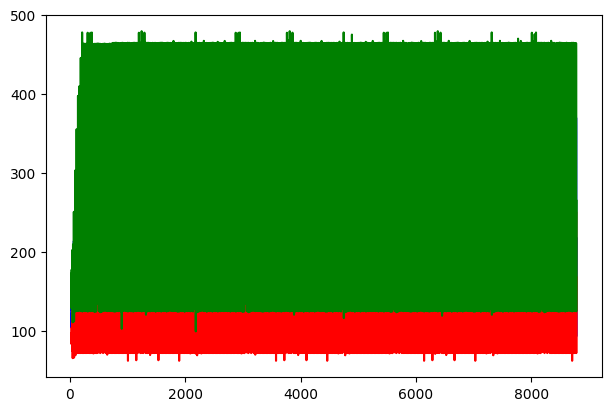

In [677]:
fig, ax = plt.subplots(1,1, figsize = (6,4), constrained_layout=True)

ax.plot(df_price_concat['Expected Price'].iloc[24:], 'b', label='Expected Price')
ax.plot(df_price_concat['P10'].iloc[24:], 'r', label='Expected Price')
ax.plot(df_price_concat['P90'].iloc[24:], 'g', label='Expected Price')

# ax.fill_between(x=np.arange(len(df_price_concat)-24),
#                 y1 = df_price_concat['P10'].iloc[24:],
#                 y2 = df_price_concat['P90'].iloc[24:],
#                 alpha=0.7
#                )

# ax.set_xlim([])
plt.show()

# VOLUME MODEL

## NOTE:
* The above price model can be used to estimate the Expected, P10 and P90 revenue.
* The MWh generation is expected from the customer. However, in the absence of the same, a volume generation model on the lines of Price model will be developed.

## BASIC MODEL

* A simple model is to take the required quantile for a year using data from the same time and date of previous years.

In [704]:
np.percentile([0,10,20], q=[10, 50, 90])

array([ 2., 10., 18.])

In [705]:
def percentile_func(x, percentile, years_in_data):
    """
    Function takes the datetime at which the power generation estimate is required.
    It uses the previous years values at the same day-month and hour and returns the
    desired percentile.    
    """

    datetime_to_fill = x['UtcDatetime']
    percentiles_arr = []
  
    for yr in years_in_data:
        
        value = df_copy['Volume_MWh'][df_copy['UtcDatetime'] == datetime_to_fill.replace(year=yr)].values
        # print(value)
        if value.size!=0:
            percentiles_arr.append(value[0])
    
    return np.percentile(percentiles_arr, q=percentile)


In [706]:
df_price_concat.drop(index=range(0,24), inplace=True)
df_price_concat.reset_index(inplace=True)

In [707]:
df_price_concat.drop(columns=['index'], inplace=True)
df_price_concat

,UtcDatetime,time_cosine,time_sine,Expected Price,P10,P90
0,2023-04-01 23:00:00,-0.141987,0.989868,122.548352,88.4150951159395,164.92720308956308
1,2023-04-02 00:00:00,0.823948,0.566665,118.954142,89.7776232717188,168.6048009537605
2,2023-04-02 01:00:00,0.873544,-0.486745,110.639605,87.06259825748859,141.79151013715122
3,2023-04-02 02:00:00,-0.048356,-0.998830,104.243544,83.7841756594884,128.83585299235747
4,2023-04-02 03:00:00,-0.916478,-0.400085,124.979038,98.70338638004489,154.07502994559786
...,...,...,...,...,...,...
8756,2024-03-31 19:00:00,-0.240447,0.970662,351.756434,237.67772385049523,447.9644444124192
8757,2024-03-31 20:00:00,0.763028,0.646365,233.779274,176.42182814195246,287.8281674990451
8758,2024-03-31 21:00:00,0.917916,-0.396776,93.613431,72.44203759037546,125.25051195892296
8759,2024-03-31 22:00:00,0.051960,-0.998649,165.636596,138.79465966974524,204.69913855292833


In [708]:
years_in_data.append(2024)
years_in_data

[2019, 2020, 2021, 2022, 2023, 2024, 2024]

In [709]:
percentile_func(df_copy.iloc[0], percentile=10, years_in_data=years_in_data)

np.float64(7.877916666666667)

In [710]:
df_copy.iloc[0]

UtcDatetime    2019-01-01 00:00:00
Price                        60.12
Volume_MWh               14.889867
Base Price               15.865289
time_cosine               0.213888
time_sine                 0.976858
Name: 0, dtype: object

In [711]:
df_copy.iloc[365*24]

UtcDatetime    2020-01-01 00:00:00
Price                        43.45
Volume_MWh                  3.6125
Base Price               15.865289
time_cosine              -0.988174
time_sine                -0.153338
Name: 8760, dtype: object

In [712]:
df_copy.iloc[365*48+24]

UtcDatetime    2021-01-01 00:00:00
Price                        65.73
Volume_MWh               14.276042
Base Price               15.865289
time_cosine              -0.843252
time_sine                -0.537518
Name: 17544, dtype: object

In [713]:
df_copy.iloc[365*48+24+365*24]

UtcDatetime    2022-01-01 00:00:00
Price                       149.98
Volume_MWh               38.369413
Base Price               15.865289
time_cosine               0.805779
time_sine                -0.592216
Name: 26304, dtype: object

In [714]:
df_copy.iloc[365*48+24+365*48]

UtcDatetime    2023-01-01 00:00:00
Price                        13.01
Volume_MWh               40.180871
Base Price               15.865289
time_cosine               0.261241
time_sine                 0.965274
Name: 35064, dtype: object

In [715]:
np.percentile([14.89, 3.6125, 14.276, 38.369, 40.181], q=[10,50,90])

array([ 7.8779, 14.89  , 39.4562])

In [716]:
df_final = df_price_concat.copy()
df_final.head(10)

,UtcDatetime,time_cosine,time_sine,Expected Price,P10,P90
0,2023-04-01 23:00:00,-0.141987,0.989868,122.548352,88.4150951159395,164.92720308956308
1,2023-04-02 00:00:00,0.823948,0.566665,118.954142,89.7776232717188,168.6048009537605
2,2023-04-02 01:00:00,0.873544,-0.486745,110.639605,87.06259825748859,141.79151013715122
3,2023-04-02 02:00:00,-0.048356,-0.998830,104.243544,83.7841756594884,128.83585299235747
4,2023-04-02 03:00:00,-0.916478,-0.400085,124.979038,98.70338638004489,154.07502994559786
5,2023-04-02 04:00:00,-0.765356,0.643608,143.927499,104.7436032389336,177.8658482407687
6,2023-04-02 05:00:00,0.236943,0.971523,130.164167,96.71977214548335,172.50805966302514
7,2023-04-02 06:00:00,0.975730,0.218977,125.079269,86.34704896949992,159.42521603526038
8,2023-04-02 07:00:00,0.629376,-0.777101,137.265552,92.4161125083023,168.89142108563374
9,2023-04-02 08:00:00,-0.416927,-0.908940,144.430356,98.61455626863885,174.2242397382749


In [717]:
# df_final.apply(percentile_func, axis=1, percentile=10, years_in_data=years_in_data)

In [718]:
df_copy[df_copy['UtcDatetime']==datetime.fromisoformat("2020-02-29 00:00:00")]

,UtcDatetime,Price,Volume_MWh,Base Price,time_cosine,time_sine
10176,2020-02-29,28.1,36.194129,15.865289,0.379102,0.925355


In [719]:
x = df_final.iloc[7993]
x

UtcDatetime       2024-02-29 00:00:00
time_cosine                  0.423748
time_sine                     0.90578
Expected Price             234.369994
P10                177.59520585225889
P90                288.41431809819625
Name: 7993, dtype: object

In [720]:
datetime_to_fill = x['UtcDatetime']

In [721]:
yr=2019

In [723]:
# df_copy['Volume_MWh'][df_copy['UtcDatetime'] == datetime_to_fill.replace(year=yr)]

In [725]:
datetime_to_fill.day

29

In [726]:
import calendar

In [727]:
calendar.isleap(2024)

True

In [728]:
list(filter(lambda x: calendar.isleap(x),years_in_data))

[2020, 2024, 2024]

In [729]:
def percentile_func(x, percentile, years_in_data):

    datetime_to_fill = x['UtcDatetime']
    percentiles_arr = []
    leap_years = list(filter(lambda x: calendar.isleap(x), years_in_data))
  
    if datetime_to_fill.day==29 and datetime_to_fill.month==2:
        
        years_in_data = list(filter(lambda x: calendar.isleap(x), years_in_data))

    
    for yr in years_in_data:
        
        value = df_copy['Volume_MWh'][df_copy['UtcDatetime'] == datetime_to_fill.replace(year=yr)].values
        # print(value)
        if value.size!=0:
            percentiles_arr.append(value[0])

    return np.percentile(percentiles_arr, q=percentile)


In [730]:
percentile_func(x, percentile=10, years_in_data=years_in_data)

np.float64(36.19412878787879)

In [731]:
x

UtcDatetime       2024-02-29 00:00:00
time_cosine                  0.423748
time_sine                     0.90578
Expected Price             234.369994
P10                177.59520585225889
P90                288.41431809819625
Name: 7993, dtype: object

In [732]:
df_final.head(10)

,UtcDatetime,time_cosine,time_sine,Expected Price,P10,P90
0,2023-04-01 23:00:00,-0.141987,0.989868,122.548352,88.4150951159395,164.92720308956308
1,2023-04-02 00:00:00,0.823948,0.566665,118.954142,89.7776232717188,168.6048009537605
2,2023-04-02 01:00:00,0.873544,-0.486745,110.639605,87.06259825748859,141.79151013715122
3,2023-04-02 02:00:00,-0.048356,-0.998830,104.243544,83.7841756594884,128.83585299235747
4,2023-04-02 03:00:00,-0.916478,-0.400085,124.979038,98.70338638004489,154.07502994559786
5,2023-04-02 04:00:00,-0.765356,0.643608,143.927499,104.7436032389336,177.8658482407687
6,2023-04-02 05:00:00,0.236943,0.971523,130.164167,96.71977214548335,172.50805966302514
7,2023-04-02 06:00:00,0.975730,0.218977,125.079269,86.34704896949992,159.42521603526038
8,2023-04-02 07:00:00,0.629376,-0.777101,137.265552,92.4161125083023,168.89142108563374
9,2023-04-02 08:00:00,-0.416927,-0.908940,144.430356,98.61455626863885,174.2242397382749


In [733]:
df_final["MWh_50"] = df_final.apply(percentile_func, axis=1, percentile=50, years_in_data=years_in_data)

In [734]:
df_final["MWh_10"] = df_final.apply(percentile_func, axis=1, percentile=10, years_in_data=years_in_data)
df_final["MWh_90"] = df_final.apply(percentile_func, axis=1, percentile=90, years_in_data=years_in_data)

In [735]:
df_final.head(10)

,UtcDatetime,time_cosine,time_sine,Expected Price,P10,P90,MWh_50,MWh_10,MWh_90
0,2023-04-01 23:00:00,-0.141987,0.989868,122.548352,88.4150951159395,164.92720308956308,8.797254,3.241856,12.185502
1,2023-04-02 00:00:00,0.823948,0.566665,118.954142,89.7776232717188,168.6048009537605,7.592045,2.300455,11.121241
2,2023-04-02 01:00:00,0.873544,-0.486745,110.639605,87.06259825748859,141.79151013715122,6.304782,2.009508,12.556941
3,2023-04-02 02:00:00,-0.048356,-0.998830,104.243544,83.7841756594884,128.83585299235747,6.300852,2.080578,15.236515
4,2023-04-02 03:00:00,-0.916478,-0.400085,124.979038,98.70338638004489,154.07502994559786,5.007150,1.720795,16.433456
5,2023-04-02 04:00:00,-0.765356,0.643608,143.927499,104.7436032389336,177.8658482407687,5.799811,1.858409,17.874602
6,2023-04-02 05:00:00,0.236943,0.971523,130.164167,96.71977214548335,172.50805966302514,8.575663,2.678892,21.348277
7,2023-04-02 06:00:00,0.975730,0.218977,125.079269,86.34704896949992,159.42521603526038,8.620644,2.684527,15.774072
8,2023-04-02 07:00:00,0.629376,-0.777101,137.265552,92.4161125083023,168.89142108563374,7.003409,1.766098,22.416108
9,2023-04-02 08:00:00,-0.416927,-0.908940,144.430356,98.61455626863885,174.2242397382749,7.919081,2.238456,24.108523


In [736]:
df_final.rename(columns={'P10': 'Price_10', 
                        'P90': 'Price_90',
                        'Expected Price': 'Price_50'}, inplace=True)
df_final.head(10)

,UtcDatetime,time_cosine,time_sine,Price_50,Price_10,Price_90,MWh_50,MWh_10,MWh_90
0,2023-04-01 23:00:00,-0.141987,0.989868,122.548352,88.4150951159395,164.92720308956308,8.797254,3.241856,12.185502
1,2023-04-02 00:00:00,0.823948,0.566665,118.954142,89.7776232717188,168.6048009537605,7.592045,2.300455,11.121241
2,2023-04-02 01:00:00,0.873544,-0.486745,110.639605,87.06259825748859,141.79151013715122,6.304782,2.009508,12.556941
3,2023-04-02 02:00:00,-0.048356,-0.998830,104.243544,83.7841756594884,128.83585299235747,6.300852,2.080578,15.236515
4,2023-04-02 03:00:00,-0.916478,-0.400085,124.979038,98.70338638004489,154.07502994559786,5.007150,1.720795,16.433456
5,2023-04-02 04:00:00,-0.765356,0.643608,143.927499,104.7436032389336,177.8658482407687,5.799811,1.858409,17.874602
6,2023-04-02 05:00:00,0.236943,0.971523,130.164167,96.71977214548335,172.50805966302514,8.575663,2.678892,21.348277
7,2023-04-02 06:00:00,0.975730,0.218977,125.079269,86.34704896949992,159.42521603526038,8.620644,2.684527,15.774072
8,2023-04-02 07:00:00,0.629376,-0.777101,137.265552,92.4161125083023,168.89142108563374,7.003409,1.766098,22.416108
9,2023-04-02 08:00:00,-0.416927,-0.908940,144.430356,98.61455626863885,174.2242397382749,7.919081,2.238456,24.108523


* $XY + \delta{XY} = XY + X\delta{Y} + Y\delta{X}$  

In [737]:
df_final['Expected'] = df_final['Price_50']*df_final['MWh_50']
df_final.head(10)

,UtcDatetime,time_cosine,time_sine,Price_50,Price_10,Price_90,MWh_50,MWh_10,MWh_90,Expected
0,2023-04-01 23:00:00,-0.141987,0.989868,122.548352,88.4150951159395,164.92720308956308,8.797254,3.241856,12.185502,1078.088958
1,2023-04-02 00:00:00,0.823948,0.566665,118.954142,89.7776232717188,168.6048009537605,7.592045,2.300455,11.121241,903.105255
2,2023-04-02 01:00:00,0.873544,-0.486745,110.639605,87.06259825748859,141.79151013715122,6.304782,2.009508,12.556941,697.558615
3,2023-04-02 02:00:00,-0.048356,-0.998830,104.243544,83.7841756594884,128.83585299235747,6.300852,2.080578,15.236515,656.823171
4,2023-04-02 03:00:00,-0.916478,-0.400085,124.979038,98.70338638004489,154.07502994559786,5.007150,1.720795,16.433456,625.788741
5,2023-04-02 04:00:00,-0.765356,0.643608,143.927499,104.7436032389336,177.8658482407687,5.799811,1.858409,17.874602,834.752236
6,2023-04-02 05:00:00,0.236943,0.971523,130.164167,96.71977214548335,172.50805966302514,8.575663,2.678892,21.348277,1116.244015
7,2023-04-02 06:00:00,0.975730,0.218977,125.079269,86.34704896949992,159.42521603526038,8.620644,2.684527,15.774072,1078.263845
8,2023-04-02 07:00:00,0.629376,-0.777101,137.265552,92.4161125083023,168.89142108563374,7.003409,1.766098,22.416108,961.326811
9,2023-04-02 08:00:00,-0.416927,-0.908940,144.430356,98.61455626863885,174.2242397382749,7.919081,2.238456,24.108523,1143.755749


In [738]:
df_final['delta_p_mwh'] = df_final['Price_50'] * (df_final['MWh_90']-df_final['MWh_10']) 
+ df_final['MWh_50']*(df_final['Price_90']-df_final['Price_10'])
df_final.head()

,UtcDatetime,time_cosine,time_sine,Price_50,Price_10,Price_90,MWh_50,MWh_10,MWh_90,Expected,delta_p_mwh
0,2023-04-01 23:00:00,-0.141987,0.989868,122.548352,88.4150951159395,164.92720308956308,8.797254,3.241856,12.185502,1078.088958,1096.029062
1,2023-04-02 00:00:00,0.823948,0.566665,118.954142,89.7776232717188,168.6048009537605,7.592045,2.300455,11.121241,903.105255,1049.269030
2,2023-04-02 01:00:00,0.873544,-0.486745,110.639605,87.06259825748859,141.79151013715122,6.304782,2.009508,12.556941,697.558615,1166.963904
3,2023-04-02 02:00:00,-0.048356,-0.998830,104.243544,83.7841756594884,128.83585299235747,6.300852,2.080578,15.236515,656.823171,1371.421550
4,2023-04-02 03:00:00,-0.916478,-0.400085,124.979038,98.70338638004489,154.07502994559786,5.007150,1.720795,16.433456,625.788741,1838.774210


In [739]:
df_final['P10'] = df_final['Price_10']*df_final['MWh_50']
df_final['P90'] = df_final['Price_90']*df_final['MWh_50']
df_final.head(10)

,UtcDatetime,time_cosine,time_sine,Price_50,Price_10,Price_90,MWh_50,MWh_10,MWh_90,Expected,delta_p_mwh,P10,P90
0,2023-04-01 23:00:00,-0.141987,0.989868,122.548352,88.4150951159395,164.92720308956308,8.797254,3.241856,12.185502,1078.088958,1096.029062,777.81003,1450.906462
1,2023-04-02 00:00:00,0.823948,0.566665,118.954142,89.7776232717188,168.6048009537605,7.592045,2.300455,11.121241,903.105255,1049.269030,681.595797,1280.055313
2,2023-04-02 01:00:00,0.873544,-0.486745,110.639605,87.06259825748859,141.79151013715122,6.304782,2.009508,12.556941,697.558615,1166.963904,548.91072,893.964589
3,2023-04-02 02:00:00,-0.048356,-0.998830,104.243544,83.7841756594884,128.83585299235747,6.300852,2.080578,15.236515,656.823171,1371.421550,527.911714,811.775677
4,2023-04-02 03:00:00,-0.916478,-0.400085,124.979038,98.70338638004489,154.07502994559786,5.007150,1.720795,16.433456,625.788741,1838.774210,494.222624,771.476728
5,2023-04-02 04:00:00,-0.765356,0.643608,143.927499,104.7436032389336,177.8658482407687,5.799811,1.858409,17.874602,834.752236,2305.170631,607.493061,1031.588233
6,2023-04-02 05:00:00,0.236943,0.971523,130.164167,96.71977214548335,172.50805966302514,8.575663,2.678892,21.348277,1116.244015,2430.084879,829.43616,1479.370964
7,2023-04-02 06:00:00,0.975730,0.218977,125.079269,86.34704896949992,159.42521603526038,8.620644,2.684527,15.774072,1078.263845,1637.230782,744.367164,1374.348022
8,2023-04-02 07:00:00,0.629376,-0.777101,137.265552,92.4161125083023,168.89142108563374,7.003409,1.766098,22.416108,961.326811,2834.534939,647.227842,1182.815714
9,2023-04-02 08:00:00,-0.416927,-0.908940,144.430356,98.61455626863885,174.2242397382749,7.919081,2.238456,24.108523,1143.755749,3158.701452,780.936702,1379.695943


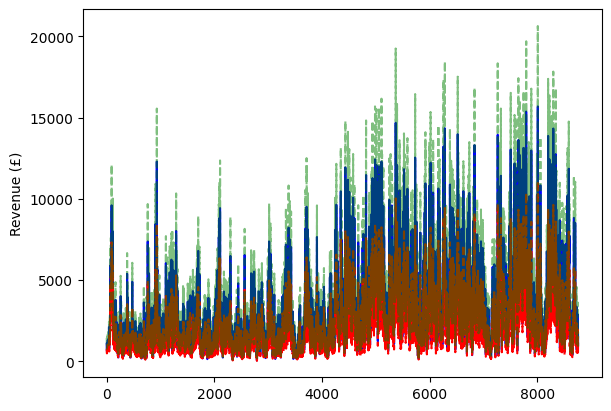

In [741]:
fig, ax = plt.subplots(1,1, figsize = (6,4), constrained_layout=True)

ax.plot(df_final['Expected'], 'b', label='Original')
ax.plot(df_final['P10'], 'r--', label='Original')
ax.plot(df_final['P90'], 'g--', alpha=0.5, label='Original')

ax.set_ylabel("Total Revenue (£)")
plt.show()

In [951]:
len(df_final)

8761

In [745]:
df_final[["UtcDatetime","Price_10", "Price_50", "Price_90", "MWh_50","P10", "Expected", "P90"]].to_csv("wind_energy_revenue_forecast.csv")

In [799]:
df_final[["Expected"]].sum()

Expected    2.722552e+07
dtype: float64

In [800]:
df_final[["P10"]].sum()

P10    20207881.918006
dtype: object

In [801]:
df_final[["P90"]].sum()

P90    34223400.691764
dtype: object

In [678]:
fft_mwh = fft(df_copy['Volume_MWh'])

In [679]:
len(fft_mwh)

37247

In [680]:
sampling_rate = 1/3600 # Hz

In [681]:
freq_values = fftfreq(len(fft_mwh), d=3600)
freq_values[:10]

array([0.00000000e+00, 7.45772217e-09, 1.49154443e-08, 2.23731665e-08,
       2.98308887e-08, 3.72886109e-08, 4.47463330e-08, 5.22040552e-08,
       5.96617774e-08, 6.71194996e-08])

In [682]:
freq_in_periods = 1/freq_values * sampling_rate

/tmp/ipykernel_380706/465146520.py:1: RuntimeWarning: divide by zero encountered in divide
  freq_in_periods = 1/freq_values * sampling_rate


## FFT

### PLOT 6: FFT of Generation

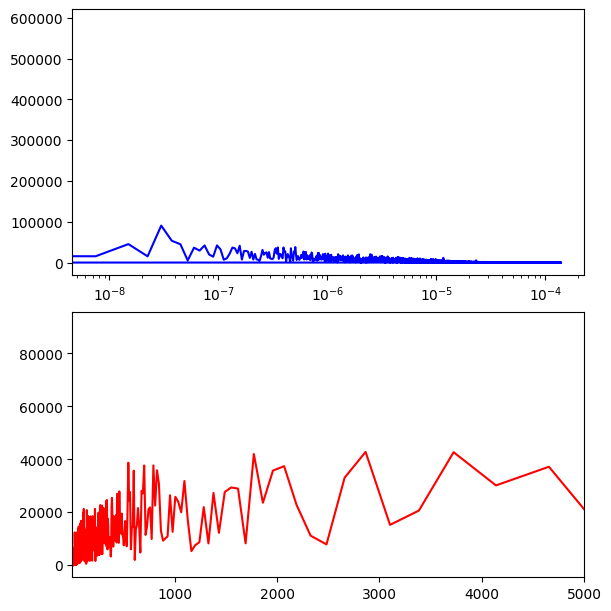

In [803]:
fig, ax = plt.subplots(2,1, figsize=(6, 6), constrained_layout=True)

ax[0].semilogx(freq_values, np.abs(fft_mwh), 'b', label="Frequency space")
ax[1].plot(freq_in_periods, np.abs(fft_mwh), 'r', label="Time space")

# ax[0].set_xlim([2*10**(-5), 5*10**(-5)])
ax[1].set_xlim([1,5000])
# ax[1].set_ylim([90000,100000])
plt.show()

#### NOTE

* There appears to be multiple frequencies in Power generation cycles.
* Selecting only the strongest frequency between $10^-8$ and $10^-7$ for preliminary investigation

### Strongest frequency

In [684]:
freq_values_one_side = freq_values[:len(fft_mwh)//2].copy()
freq_periods_one_side = freq_in_periods[:len(fft_mwh)//2].copy()
fft_mwh_one_side = fft_mwh[:len(fft_mwh)//2].copy()

In [685]:
freq_0_abs_val = np.max(abs(fft_mwh_one_side[(freq_periods_one_side>8000) & (freq_periods_one_side<10000)]))
freq_0_abs_val

np.float64(91237.85682739016)

In [686]:
freq_0_idx = np.argwhere(abs(fft_mwh_one_side) == freq_0_abs_val)
freq_0_idx

array([[4]])

In [687]:
freq_0_time = freq_periods_one_side[freq_0_idx[0]]
freq_0_time

array([9311.75])

In [688]:
freq_0 = freq_values_one_side[freq_0_idx[0]]
freq_0

array([2.98308887e-08])

In [689]:
# corresponding time value in hours
time_0 = 1/freq_0*sampling_rate
time_0

array([9311.75])

In [690]:
9311.75/24

387.9895833333333

#### NOTE
* This correspond to a frequency of ~388 days.

### INVERSE: Strongest frequency

* There are two peaks

In [691]:
freq_0_idx[0]

array([4])

In [692]:
freq_mwh_indices = np.arange(2,6,2)
freq_mwh_indices

array([2, 4])

In [693]:
# zero all fft mwh values except for these indices and the corresponding indices of the negative frequencies
fft_mwh[-1*freq_mwh_indices]

array([-42541.57725095-17490.86995097j,  58798.38885403-69764.57544217j])

In [694]:
fft_mwh[freq_mwh_indices]

array([-42541.57725095+17490.86995097j,  58798.38885403+69764.57544217j])

In [695]:
fft_mwh_copy = np.zeros_like(fft_mwh)

In [696]:
fft_mwh_copy[freq_mwh_indices] = fft_mwh[freq_mwh_indices]

In [697]:
fft_mwh_copy[freq_mwh_indices]

array([-42541.57725095+17490.86995097j,  58798.38885403+69764.57544217j])

In [698]:
fft_mwh_copy[-1*freq_mwh_indices] = fft_mwh[-1*freq_mwh_indices]

In [699]:
fft_mwh_copy[-1*freq_mwh_indices]

array([-42541.57725095-17490.86995097j,  58798.38885403-69764.57544217j])

In [700]:
# verifying
np.where(fft_mwh_copy==0.0)[0].size == len(fft_mwh) - 2 * len(freq_mwh_indices)

True

In [701]:
ifft_mwh = ifft(fft_mwh_copy)

In [702]:
len(ifft_mwh)

37247

#### PLOT 7

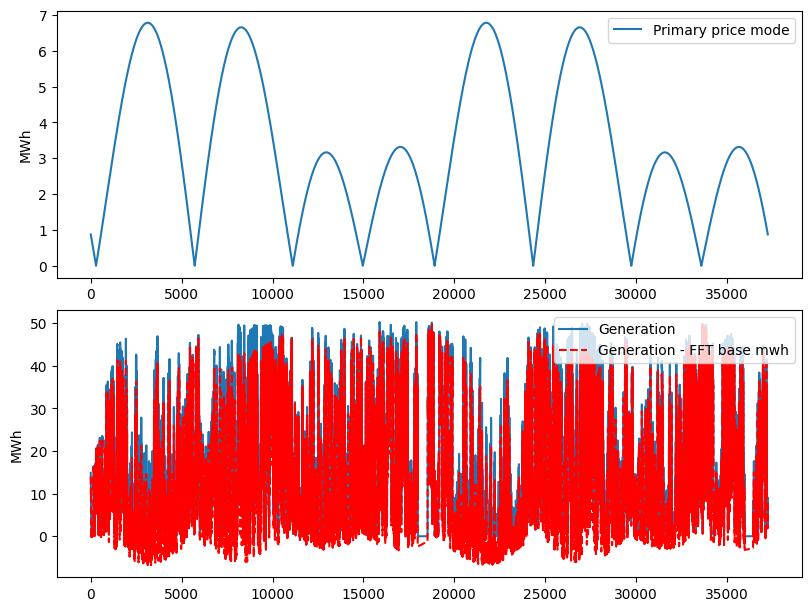

In [881]:
fig, ax = plt.subplots(2,1, figsize=(8,6), constrained_layout=True)
ax[0].plot(abs(ifft_mwh), label='Primary price mode')
# ax[0].set_xlim([0,48])
ax[1].plot(df_copy['Volume_MWh'], label="Generation")
ax[1].plot(df_copy['Volume_MWh'] - abs(ifft_mwh), 'r--', label="Generation - FFT base mwh")
[i.legend() for i in ax]
[i.set_ylabel('MWh') for i in ax]
plt.show()

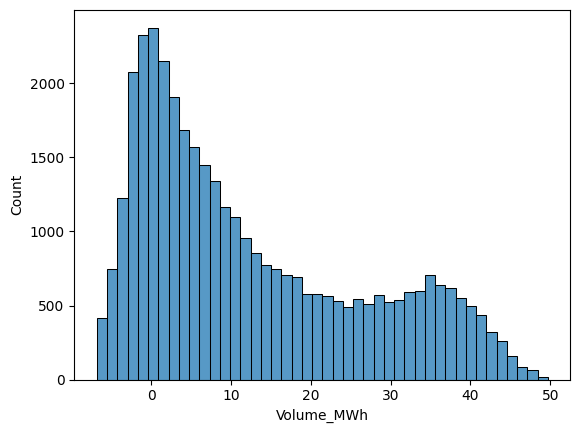

In [882]:
sns.histplot(df_copy['Volume_MWh'] - abs(ifft_mwh))
plt.show()

#### NOTE
* Clearly, the chosen frequencies are not sufficient as the bottom graph in PLOT 7 still shows certain patterns.
* This is corroborated by the above histogram which still shows a non-normal distribution.
* Therefore, selecting all frequencies below $10^{-6} Hz$ and zeroing all frequencies beyond this point and inverting. 

### INVERSE: $<=10^{-6} Hz$ 

In [818]:
fft_mwh_copy = np.copy(fft_mwh)

In [819]:
threshold_freq = 10**(-6)

In [820]:
freq_values_copy =  np.copy(freq_values)
freq_values_copy[freq_values_copy > threshold_freq]=0.0
freq_values_copy[freq_values_copy < -1*threshold_freq]=0.0

In [821]:
highest_pos_freq = freq_values_copy.max()
highest_pos_freq

np.float64(9.993347711821681e-07)

In [921]:
1/highest_pos_freq * sampling_rate/24

np.float64(11.581778606965175)

In [822]:
highest_neg_freq = freq_values_copy.min()
highest_neg_freq

np.float64(-9.993347711821681e-07)

In [823]:
fft_mwh_copy[freq_values > threshold_freq] = 0.0
fft_mwh_copy[freq_values < -1*threshold_freq] = 0.0

In [824]:
ifft_volume = ifft(fft_mwh_copy)

In [828]:
fft_mwh_copy[0]

np.complex128(590783.9289457072-0j)

In [829]:
fft_mwh_copy[-1]

np.complex128(1699.87139342117+16142.792238790666j)

In [830]:
fft_mwh_copy[fft_mwh_copy==0.0].size

36978

In [911]:
non_zero_frequencies = len(fft_mwh_copy) - fft_mwh_copy[fft_mwh_copy==0.0].size
non_zero_frequencies

269

In [832]:
x1 = np.array([1,2,3])
t1 = np.array([0.1, 0.2, 0.3])
x1*t1

array([0.1, 0.4, 0.9])

In [914]:
freq_values_copy[freq_values_copy>0.0].min()

np.float64(7.457722173001255e-09)

In [920]:
1/freq_values_copy[1:][freq_values_copy[1:]>0.0].min() * sampling_rate/24

np.float64(1551.9583333333337)

In [835]:
ifft_volume_manual_0 = fft_mwh_copy.sum()/len(fft_mwh_copy)
ifft_volume_manual_0

np.complex128(8.528291448146643+0j)

In [834]:
ifft_volume[0]

np.complex128(8.528291448146652-6.250990513433823e-15j)

In [862]:
time_factor = 2*np.pi*np.arange(0, len(fft_mwh_copy))/len(fft_mwh_copy)

In [870]:
ifft_volume_manual = [np.dot(fft_mwh_copy, np.exp(-1j * i * time_factor))/len(fft_mwh_copy) for i in range(0, len(fft_mwh_copy))]

In [874]:
ifft_volume_manual_inverse = [np.dot(fft_mwh_copy, np.exp(-1j * (len(fft_mwh_copy)-i) * time_factor))/len(fft_mwh_copy) for i in range(0, len(fft_mwh_copy))]

In [876]:
ifft_test = lambda t:np.dot(fft_mwh_copy, np.exp(-1j * (len(fft_mwh_copy)-t) * time_factor))/len(fft_mwh_copy)

In [877]:
ifft_test(len(fft_mwh_copy)+100)

np.complex128(2.7802905690958966+1.7776254272577435e-13j)

In [867]:
abs(ifft_volume_manual_100)

np.float64(33.95360576520042)

In [868]:
ifft_volume[20001]

np.complex128(2.5086299637914804+1.1525263759143611e-14j)

In [850]:
freq_values*10

array([ 0.00000000e+00,  7.45772217e-08,  1.49154443e-07, ...,
       -2.23731665e-07, -1.49154443e-07, -7.45772217e-08], shape=(37247,))

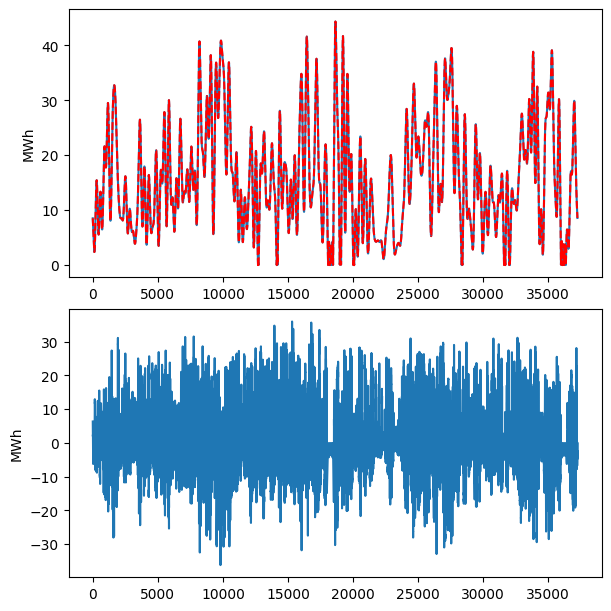

In [875]:
fig, ax = plt.subplots(2,1, figsize=(6,6), constrained_layout=True)
ax[0].plot(abs(ifft_volume), label='Primary price mode')
ax[0].plot(abs(np.array(ifft_volume_manual_inverse)), 'r--', label='Primary price mode')

# ax[0].set_xlim([0,48])
# ax[1].plot(df_copy['Volume_MWh'], label="Generation")
ax[1].plot(df_copy['Volume_MWh'] - abs(ifft_volume), label="Actual - base fft mwh")
[i.set_ylabel('MWh') for i in ax]
plt.show()

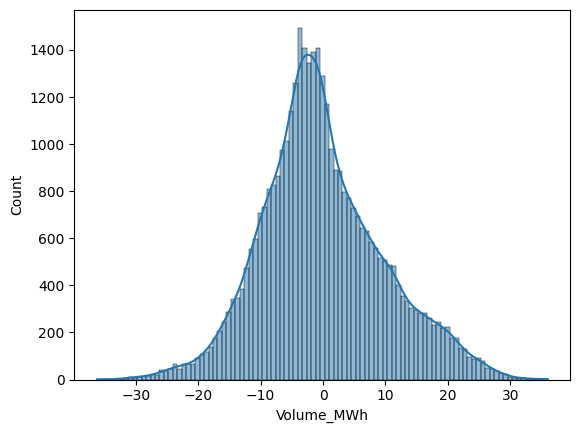

In [940]:
sns.histplot(df_copy['Volume_MWh'] - abs(ifft_volume), kde=True)
plt.show()

#### NOTE

* Given the close-to-normal distribution of the power generation component, the Power generation can be modelled using a combination of 269 frequencies with the largest time period corresponding to ~ 12 hours price cycle.

### FFT function

In [922]:
df_copy.iloc[0]

UtcDatetime    2019-01-01 00:00:00
Price                        60.12
Volume_MWh               14.889867
Base Price               15.865289
time_cosine               0.213888
time_sine                 0.976858
Name: 0, dtype: object

In [923]:
df_copy.iloc[-1]

UtcDatetime    2023-04-01 22:00:00
Price                       114.76
Volume_MWh                3.992519
Base Price                5.782357
time_cosine              -0.950014
time_sine                 0.312207
Name: 37246, dtype: object

In [925]:
x = df_copy.iloc[-1, 0] - df_copy.iloc[0, 0]
x

Timedelta('1551 days 22:00:00')

In [928]:
x.total_seconds()/3600

37246.0

In [929]:
len(ifft_volume)

37247

In [930]:
ifft_test(int(x.total_seconds()/3600))

np.complex128(8.583566728168341-2.344121442537684e-15j)

In [937]:
def generation_fft_func(t, fft_filtered_arr, first_datetime_value):
    
    _N = len(fft_filtered_arr)

    time_factor = 2*np.pi*np.arange(0, _N)/_N

    time_diff = t - first_datetime_value
    
    n =  int(time_diff.total_seconds()/3600)
    # must be in hours

    return abs(np.dot(fft_filtered_arr, np.exp(-1j * (_N - n) * time_factor))/_N)

In [965]:
generation_fft_func(df_copy.iloc[-1, 0], fft_mwh_copy, df_copy.iloc[0,0])

np.float64(8.583566728168341)

### Distribution sampling function

In [939]:
from sklearn.neighbors import KernelDensity

In [941]:
kde = KernelDensity(bandwidth=1.0, kernel='gaussian')

In [946]:
volume_fft_subtracted = df_copy['Volume_MWh'].to_numpy() - abs(ifft_volume)
volume_fft_subtracted[:5]

array([6.36157598, 5.68961684, 5.52631996, 4.92746792, 2.14429734])

In [982]:
volume_fft_subtracted.min()

np.float64(-36.20883673459623)

In [983]:
abs(ifft_volume).min()

np.float64(0.004797068733850058)

In [948]:
volume_fft_subtracted[:5][..., np.newaxis]

array([[6.36157598],
       [5.68961684],
       [5.52631996],
       [4.92746792],
       [2.14429734]])

In [950]:
kde_fit = kde.fit(volume_fft_subtracted[..., np.newaxis])

In [952]:
sampled_data = kde_fit.sample(n_samples=len(df_final))

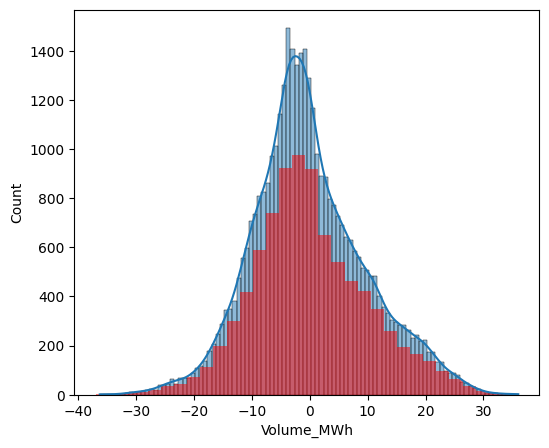

In [957]:
fig, ax = plt.subplots(1,1, figsize=(6,5))
sns.histplot(df_copy['Volume_MWh'] - abs(ifft_volume), kde=True)
# sns.histplot(sampled_data, kde=True, ax=ax, color='r')
ax.hist(sampled_data, bins=32, color='r', alpha=0.5)
plt.show()

#### NOTE
* The sampled data distribution is similar to that of the original subtracted data

### PREDICTION

In [976]:
df_final_fft = df_final[["UtcDatetime"]].copy()
df_final_fft.head(5)

,UtcDatetime
0,2023-04-01 23:00:00
1,2023-04-02 00:00:00
2,2023-04-02 01:00:00
3,2023-04-02 02:00:00
4,2023-04-02 03:00:00


In [977]:
df_final_fft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8761 entries, 0 to 8760
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   UtcDatetime  8761 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 68.6 KB


In [979]:
df_final_fft["Mwh_estimate"] = df_final['UtcDatetime'].map(lambda x: generation_fft_func(x, 
                                             fft_filtered_arr=fft_mwh_copy, 
                                             first_datetime_value=df_copy.iloc[0,0]
                                            ))

In [980]:
df_final_fft["Mwh_estimate"] = df_final_fft["Mwh_estimate"] + sampled_data.flatten()

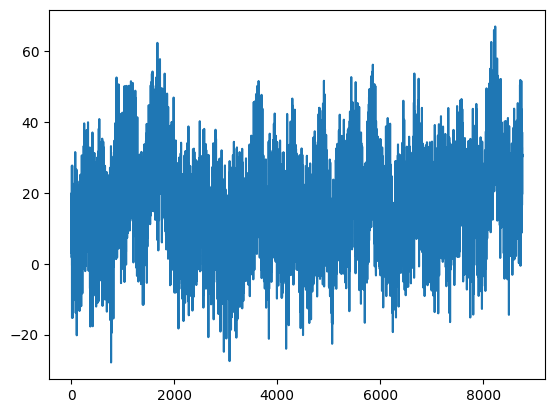

In [981]:
plt.plot(df_final_fft["Mwh_estimate"])
plt.show()

In [984]:
df_final.columns

Index(['UtcDatetime', 'time_cosine', 'time_sine', 'Price_50', 'Price_10',
       'Price_90', 'MWh_50', 'MWh_10', 'MWh_90', 'Expected', 'delta_p_mwh',
       'P10', 'P90'],
      dtype='object')

In [985]:
df_final_fft[["Price_50", "Price_10", "Price_90"]] = df_final[["Price_50", "Price_10", "Price_90"]]

In [986]:
df_final_fft["Expected"] = df_final_fft["Price_50"]*df_final_fft["Mwh_estimate"]
df_final_fft['P10'] = df_final_fft['Price_10']*df_final_fft['Mwh_estimate']
df_final_fft['P90'] = df_final_fft['Price_90']*df_final_fft['Mwh_estimate']
df_final_fft.head(10)

,UtcDatetime,Mwh_estimate,Price_50,Price_10,Price_90,Expected,P10,P90
0,2023-04-01 23:00:00,3.091103,122.548352,88.4150951159395,164.92720308956308,378.809552,273.300145,509.806934
1,2023-04-02 00:00:00,6.279770,118.954142,89.7776232717188,168.6048009537605,747.004626,563.782805,1058.799332
2,2023-04-02 01:00:00,15.485475,110.639605,87.06259825748859,141.79151013715122,1713.306796,1348.205651,2195.708824
3,2023-04-02 02:00:00,6.452136,104.243544,83.7841756594884,128.83585299235747,672.593496,540.586874,831.266412
4,2023-04-02 03:00:00,19.922540,124.979038,98.70338638004489,154.07502994559786,2489.899873,1966.422162,3069.565945
5,2023-04-02 04:00:00,17.464361,143.927499,104.7436032389336,177.8658482407687,2513.601736,1829.280051,3106.3133
6,2023-04-02 05:00:00,1.728972,130.164167,96.71977214548335,172.50805966302514,225.050263,167.225824,298.261688
7,2023-04-02 06:00:00,9.156759,125.079269,86.34704896949992,159.42521603526038,1145.320776,790.659152,1459.818346
8,2023-04-02 07:00:00,3.071363,137.265552,92.4161125083023,168.89142108563374,421.592328,283.843423,518.726852
9,2023-04-02 08:00:00,27.598339,144.430356,98.61455626863885,174.2242397382749,3986.037952,2721.597978,4808.299672


In [987]:
df_final_fft['Expected'].sum()

np.float64(28487183.31579017)

In [988]:
df_final_fft['P10'].sum()

np.float64(21086451.143075496)

In [989]:
df_final_fft['P90'].sum()

np.float64(35853166.25798377)

In [990]:
df_final_fft[["UtcDatetime","Price_10", "Price_50", "Price_90", "Mwh_estimate","P10", "Expected", "P90"]].to_csv("wind_energy_revenue_forecast_fft-model.csv")

### Auto-correlation

In [756]:
acf_volume = sm.tsa.acf(df_copy['Volume_MWh'].to_numpy(), nlags=len(df_copy))

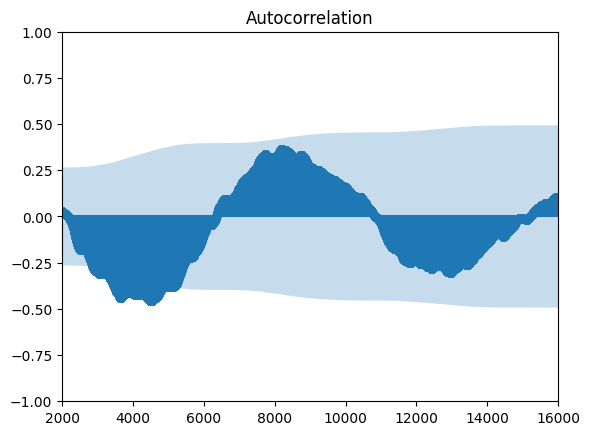

In [761]:
tsaplots.plot_acf(acf_volume, lags=len(df_copy)-1)
plt.xlim([2000,16000])
plt.show()

In [759]:
4000/24

166.66666666666666